# Transformer (Ko-En) 번역기 Mecab 처리 버전
---
### 프로젝트 목표
한국어-영어 번역을 위한 트랜스포머 모델 베이스라인에서 mecab을 처리한 sentencepiece 실험하기

### 실험 설계 근거
한국어는 교착어이기 때문에 subword 기반인 sentencepiece가 한계가 있다.

따라서 형태소 기반의 Mecab으로 데이터를 처리해준 뒤에 subword로 학습을 하면 희귀한 표현에 강건해지고, OOV가 줄어들 것이다.

- Baseline: 형태소 분석 없음, sentencepice(unigram, vacab= 20k)
- 실험 1 : Mecab 적용, sentencepice(unigram, vacab= 20k)

# 평가 방식 추가

11번 노드 마지막에 새로운 평가 방식으로 `GLUE`가 제시되었다.

그러나 General Language Understanding Evaluation은 자연어 모델의 언어 이해 능력을 종합적으로 평가하기 위한 벤치마크이다.

모델이 종합적으로 문장을 잘 이해하는 지 평가하는 모델이므로 이번 과제에는 적합하지 않았다.

-> 문장 분류, 유사도, 추론 과제에 적합하다.

그래서 대안으로 `chrF`와 `COMET`이라는 평가 지표를 찾게 됐다.

## chrF vs BLEU

- 문자 n-gram 기반 평가 지표이다.
- BELU는 `학교에`와 `학교로`를 n-gram이 불일치해서 점수를 낮게하는 경향이 있다.
- 하지만 chrF는 `학`, `학교`가 겹치기 때문에 부분 점수가 살아난다.
- 즉, 교착어인 한국어에 적합한 방식이다.

## COMET vs BLEU

- 신경망 기반 의미 평가로, 보통 인간 판단과의 상관관계가 높다고 한다.
- BELU는 n-gram이 정확히 일치해야만 하는 문제로 앞서 설명했듯이 동의어와 어순 변화에 취약하다.
- COMET은 사전학습된 언어 모델 기반으로 문장의 의미표현을 임베딩으로 학습한 것이다.
- 이때 학습 데이터는 사람이 평가한 번역 품질 점수를 레이블로 사용하기 때문에 실제 인간 평가와 상관이 높다.


## 1. 라이브러리 설치 및 임포트

In [1]:
#mecab 설치

!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 34.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]
fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
/home/jovyan/work/Mecab-ko-for-Google-Colab
install_mecab-ko_on_colab_light_220429.sh: line 4: cd: /content: No such file or directory
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2025-09-10 07:20:13--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 13.200.41.134, 13.200.41.135, 13.200.41.136, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.134|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://bbuseruploads.s3.amazonaws.com/eunjeo

In [1]:
!pip install sentencepiece
!pip install nltk

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import re
import os
from tqdm.notebook import tqdm
import math
import random

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

## 2. 하이퍼파라미터 및 설정

In [2]:
# Model Hyperparameters
SRC_VOCAB_SIZE = 20000
TGT_VOCAB_SIZE = 20000
D_MODEL = 512
N_LAYERS = 6
N_HEADS = 8
D_FF = 2048
DROPOUT = 0.1
MAX_LEN = 50

# Training Hyperparameters
BATCH_SIZE = 64
EPOCHS = 1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 3. 데이터 준비 및 전처리

In [3]:
# 1. 데이터 경로 설정
data_dir = '/home/jovyan/work/transformer/data'
train_kor_path = os.path.join(data_dir, 'korean-english-park.train.ko')
train_eng_path = os.path.join(data_dir, 'korean-english-park.train.en')
dev_kor_path = os.path.join(data_dir, 'korean-english-park.dev.ko')
dev_eng_path = os.path.join(data_dir, 'korean-english-park.dev.en')
test_kor_path = os.path.join(data_dir, 'korean-english-park.test.ko')
test_eng_path = os.path.join(data_dir, 'korean-english-park.test.en')

# 2. 원본 데이터 로딩
with open(train_kor_path, "r", encoding='utf-8') as f: train_kor_raw = f.read().splitlines()
with open(train_eng_path, "r", encoding='utf-8') as f: train_eng_raw = f.read().splitlines()
with open(dev_kor_path, "r", encoding='utf-8') as f: dev_kor_raw = f.read().splitlines()
with open(dev_eng_path, "r", encoding='utf-8') as f: dev_eng_raw = f.read().splitlines()
with open(test_kor_path, "r", encoding='utf-8') as f: test_kor_raw = f.read().splitlines()
with open(test_eng_path, "r", encoding='utf-8') as f: test_eng_raw = f.read().splitlines()

print(f"Train: {len(train_kor_raw)}, Dev: {len(dev_kor_raw)}, Test: {len(test_kor_raw)}")

Train: 94123, Dev: 1000, Test: 2000


In [4]:
# 3. 데이터 정제 및 전처리
def preprocess_sentence(sentence):
    """구두점, 특수문자 등 불필요한 부분을 제거하고 소문자로 변환합니다."""
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

def clean_and_preprocess_corpus(kor_raw, eng_raw):
    """문장 쌍의 중복을 제거하고 각 문장을 전처리합니다."""
    # 1. zip으로 문장 쌍 생성 후 set으로 중복 제거
    cleaned_pairs = list(set(zip(kor_raw, eng_raw)))

    # 2. 각 문장 전처리
    kor_corpus, eng_corpus = [], []
    for kor, eng in cleaned_pairs:
        kor_corpus.append(preprocess_sentence(kor))
        eng_corpus.append(preprocess_sentence(eng))

    return kor_corpus, eng_corpus

# 각 데이터셋에 대해 정제 및 전처리 수행
train_kor_corpus, train_eng_corpus = clean_and_preprocess_corpus(train_kor_raw, train_eng_raw)
dev_kor_corpus, dev_eng_corpus = clean_and_preprocess_corpus(dev_kor_raw, dev_eng_raw)
test_kor_corpus, test_eng_corpus = clean_and_preprocess_corpus(test_kor_raw, test_eng_raw)

print(f"Train: {len(train_kor_corpus)}, Dev: {len(dev_kor_corpus)}, Test: {len(test_kor_corpus)}")

Train: 78968, Dev: 1000, Test: 1996


In [5]:
#=========================================================
#================추가된 Mecab 단계=========================
#=========================================================
from konlpy.tag import Mecab

# 1. Mecab 초기화
mecab = Mecab()
def mecab_tokenize_corpus(corpus):
    mecab_corpus = []
    for sentence in corpus:
        # 형태소 분리 후 공백으로 join
        morphs = mecab.morphs(sentence)
        mecab_corpus.append(" ".join(morphs))
    return mecab_corpus

# 2. 한국어 데이터셋 Mecab 처리
train_kor_mecab = mecab_tokenize_corpus(train_kor_corpus)
dev_kor_mecab   = mecab_tokenize_corpus(dev_kor_corpus)
test_kor_mecab  = mecab_tokenize_corpus(test_kor_corpus)

print("Before:", train_kor_corpus[0])
print("After :", train_kor_mecab[0])
#=========================================================
#=========================================================
#=========================================================

Before: 크리스 에론손 세기 폭스 부사장은 만개의 도토리가 만들어졌다 며 칩멍크는 주행성 동물로 동면을 취하지만 지금은 아니다 라고 말했다 .
After : 크리스 에 론 손 세기 폭스 부사장 은 만 개 의 도토리 가 만들 어 졌 다 며 칩 멍 크 는 주행성 동물 로 동면 을 취하 지만 지금 은 아니 다 라고 말 했 다 .


In [6]:
def generate_tokenizer(corpus, vocab_size, lang, pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    file = f'./{lang}_corpus.txt'
    model_prefix = f'{lang}_spm'
    with open(file, 'w', encoding='utf-8') as f:
        for row in corpus:
            f.write(str(row) + '\n')
    spm.SentencePieceTrainer.Train(
        f'--input={file} --model_prefix={model_prefix} --vocab_size={vocab_size}' + 
        f' --pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}'
    )
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f'{model_prefix}.model')
    return tokenizer

ko_tokenizer = generate_tokenizer(train_kor_mecab, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(train_eng_corpus, TGT_VOCAB_SIZE, "en")

sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=./ko_corpus.txt --model_prefix=ko_spm --vocab_size=20000 --pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: ./ko_corpus.txt
  input_format: 
  model_prefix: ko_spm
  model_type: UNIGRAM
  vocab_size: 20000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
 

## 4. 데이터 증강 (Lexical Substitution)

In [7]:
print("Data augmentation is optional. Skipping for baseline.")

Data augmentation is optional. Skipping for baseline.


## 5. 데이터셋 및 DataLoader 구축

In [8]:
class TranslationDataset(Dataset):
    def __init__(self, src_corpus, tgt_corpus, src_tokenizer, tgt_tokenizer):
        self.src_corpus = src_corpus # 한국어 문장 리스트
        self.tgt_corpus = tgt_corpus # 영어 문장 리스트
        self.src_tokenizer = src_tokenizer # 한국어 토크나이저
        self.tgt_tokenizer = tgt_tokenizer # 영어 토크나이저

    def __len__(self):
        return len(self.src_corpus) # 길이 알기 위해서

    def __getitem__(self, idx):
        src = self.src_tokenizer.encode_as_ids(self.src_corpus[idx])
        tgt = self.tgt_tokenizer.encode_as_ids(self.tgt_corpus[idx])

        # 텐서의 데이터 타입을 torch.long으로 명시적으로 지정합니다. 왜냐하면 모델에 바로 넣을 수 있는 형태로 만들기 위해서.
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

def collate_fn(batch):
    """배치 내의 시퀀스들을 패딩하여 동일한 길이로 만듭니다. 왜냐하면 문장 길이가 제각각이어서."""
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch:
        src_batch.append(src_sample)
        tgt_batch.append(tgt_sample)

    src_padded = torch.nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=ko_tokenizer.pad_id())
    tgt_padded = torch.nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=en_tokenizer.pad_id())
    return src_padded, tgt_padded
# 최종 반환은 모든 문장이 같은 길이가 된 텐서 2개
# (batch size, max_src_len)과 (batch size, max_tgt_len)

# Dataset 및 DataLoader 인스턴스 생성
train_dataset = TranslationDataset(train_kor_mecab, train_eng_corpus, ko_tokenizer, en_tokenizer)
valid_dataset = TranslationDataset(dev_kor_mecab, dev_eng_corpus, ko_tokenizer, en_tokenizer)
test_dataset = TranslationDataset(test_kor_mecab, test_eng_corpus, ko_tokenizer, en_tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=4)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=4)

print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in valid_loader: {len(valid_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Number of batches in train_loader: 1234
Number of batches in valid_loader: 16
Number of batches in test_loader: 32


## 6. 트랜스포머 모델 정의

In [9]:
class PositionalEncoding(nn.Module):
    """
    입력 임베딩에 위치 정보를 추가하는 클래스입니다.
    Transformer 모델은 순서 정보가 없으므로, 토큰의 위치를 알려주기 위해 sin/cos 함수를 사용합니다.
    이 방식은 고정 위치 인코딩으로, 학습되지 않는 파라미터(buffer)로 등록됩니다.
    """
    def __init__(self, emb_size: int, dropout: float, maxlen: int = 5000):
        super(PositionalEncoding, self).__init__()
        # sin/cos 함수에 사용할 div_term 계산: 주파수 조절을 위한 값
        div_term = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))
        # 각 위치(0~maxlen)에 대한 인덱스 생성
        position = torch.arange(maxlen).unsqueeze(1)
        # 위치 임베딩 행렬 초기화 (maxlen, emb_size)
        pos_embedding = torch.zeros(maxlen, emb_size)
        # 짝수 인덱스: sin 함수 적용
        pos_embedding[:, 0::2] = torch.sin(position * div_term)
        # 홀수 인덱스: cos 함수 적용
        pos_embedding[:, 1::2] = torch.cos(position * div_term)
        # 배치 차원 추가 (1, maxlen, emb_size)
        pos_embedding = pos_embedding.unsqueeze(0)
        self.dropout = nn.Dropout(dropout)
        # 학습되지 않는 파라미터로 등록
        self.register_buffer('pos_embedding', pos_embedding)

    def forward(self, token_embedding):
        """
        Args:
            token_embedding: (batch_size, seq_len, emb_size)
        Returns:
            token_embedding + pos_embedding: 위치 정보가 더해진 임베딩
        """
        return self.dropout(token_embedding + self.pos_embedding[:, :token_embedding.size(1), :])

class MultiHeadAttention(nn.Module):
    """
    다중 헤드 어텐션 메커니즘을 구현한 클래스.
    쿼리, 키, 값 행렬을 여러 헤드로 분할하여 병렬로 어텐션을 계산하고, 결과를 결합합니다.
    """
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads  # 각 헤드의 차원
        # 쿼리, 키, 값 행렬을 위한 선형 변환 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        # 최종 출력 선형 변환 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        스케일드 닷-프로덕트 어텐션 계산.
        Args:
            Q: 쿼리 행렬
            K: 키 행렬
            V: 값 행렬
            mask: 어텐션 마스크 (선택적)
        Returns:
            out: 어텐션 가중치 적용된 값 행렬
            attentions: 어텐션 가중치 행렬
        """
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1, -2))  # QK^T 계산
        scaled_qk = QK / math.sqrt(d_k)  # 스케일링
        if mask is not None:
            scaled_qk += (mask * -1e9)  # 마스크 적용 (매우 작은 값 더하기)
        attentions = nn.Softmax(dim=-1)(scaled_qk)  # 소프트맥스 적용
        out = torch.matmul(attentions, V)  # 가중치 적용
        return out, attentions

    def split_heads(self, x):
        """
        입력 텐서를 여러 헤드로 분할.
        Args:
            x: (batch_size, seq_len, d_model)
        Returns:
            x: (batch_size, num_heads, seq_len, depth)
        """
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)  # 차원 재배치

    def combine_heads(self, x):
        """
        분할된 헤드를 다시 결합.
        Args:
            x: (batch_size, num_heads, seq_len, depth)
        Returns:
            x: (batch_size, seq_len, d_model)
        """
        bsz, _, seq_len, _ = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(bsz, seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        """
        Args:
            Q: 쿼리 입력 (batch_size, seq_len, d_model)
            K: 키 입력
            V: 값 입력
            mask: 어텐션 마스크
        Returns:
            out: 어텐션 적용된 출력
            attention_weights: 어텐션 가중치
        """
        # 헤드 분할 후 어텐션 계산
        WQ = self.split_heads(self.W_q(Q))
        WK = self.split_heads(self.W_k(K))
        WV = self.split_heads(self.W_v(V))
        out, attention_weights = self.scaled_dot_product_attention(WQ, WK, WV, mask)
        # 헤드 결합 후 선형 변환
        out = self.combine_heads(out)
        out = self.linear(out)
        return out, attention_weights

class PoswiseFeedForwardNet(nn.Module):
    """
    포지션 와이즈 피드포워드 네트워크.
    각 위치별로 독립적으로 적용되는 2층 완전 연결 네트워크 (ReLU 활성화 함수 사용).
    """
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)  # 첫 번째 레이어 (차원 확장)
        self.fc2 = nn.Linear(d_ff, d_model)  # 두 번째 레이어 (원래 차원으로 복원)
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        Args:
            x: (batch_size, seq_len, d_model)
        Returns:
            x: (batch_size, seq_len, d_model)
        """
        return self.fc2(self.relu(self.fc1(x)))

class EncoderLayer(nn.Module):
    """
    인코더의 단일 레이어.
    셀프 어텐션과 피드포워드 네트워크를 포함하며, 레이어 정규화와 드롭아웃을 적용합니다.
    """
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)  # 첫 번째 정규화
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)  # 두 번째 정규화
        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Args:
            x: 입력 텐서
            mask: 패딩 마스크
        Returns:
            out: 출력 텐서
            enc_attn: 셀프 어텐션 가중치
        """
        residual = x
        # 셀프 어텐션 + 드롭아웃 + 잔차 연결
        out, enc_attn = self.enc_self_attn(self.norm_1(x), self.norm_1(x), self.norm_1(x), mask)
        out = self.do(out) + residual
        residual = out
        # 피드포워드 네트워크 + 드롭아웃 + 잔차 연결
        out = self.ffn(self.norm_2(out))
        out = self.do(out) + residual
        return out, enc_attn

class DecoderLayer(nn.Module):
    """
    디코더의 단일 레이어.
    셀프 어텐션, 인코더-디코더 어텐션, 피드포워드 네트워크를 포함합니다.
    """
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)  # 셀프 어텐션
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)  # 인코더-디코더 어텐션
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        """
        Args:
            x: 디코더 입력
            enc_out: 인코더 출력
            dec_enc_mask: 디코더-인코더 어텐션 마스크
            padding_mask: 패딩 마스크
        Returns:
            out: 출력 텐서
            dec_attn: 셀프 어텐션 가중치
            dec_enc_attn: 인코더-디코더 어텐션 가중치
        """
        residual = x
        # 셀프 어텐션 (look-ahead 마스크 적용)
        out, dec_attn = self.dec_self_attn(self.norm_1(x), self.norm_1(x), self.norm_1(x), mask=padding_mask)
        out = self.do(out) + residual
        residual = out
        # 인코더-디코더 어텐션
        out, dec_enc_attn = self.enc_dec_attn(self.norm_2(out), enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out) + residual
        residual = out
        # 피드포워드 네트워크
        out = self.ffn(self.norm_3(out))
        out = self.do(out) + residual
        return out, dec_attn, dec_enc_attn

class Encoder(nn.Module):
    """
    인코더 전체 구조.
    임베딩 레이어, 위치 인코딩, 여러 개의 인코더 레이어로 구성됩니다.
    """
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout, vocab_size):
        super(Encoder, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)  # 토큰 임베딩
        self.pos_encoding = PositionalEncoding(d_model, dropout)  # 위치 인코딩
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, mask):
        """
        Args:
            x: 입력 시퀀스 (batch_size, seq_len)
            mask: 패딩 마스크
        Returns:
            out: 인코더 출력
            enc_attns: 각 레이어의 어텐션 가중치 리스트
        """
        out = self.embedding(x) * math.sqrt(self.d_model)  # 임베딩 스케일링
        out = self.pos_encoding(out)  # 위치 인코딩 추가
        enc_attns = []
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

class Decoder(nn.Module):
    """
    디코더 전체 구조.
    임베딩 레이어, 위치 인코딩, 여러 개의 디코더 레이어로 구성됩니다.
    """
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout, vocab_size):
        super(Decoder, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, dropout)
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        """
        Args:
            x: 디코더 입력 시퀀스
            enc_out: 인코더 출력
            dec_enc_mask: 디코더-인코더 어텐션 마스크
            padding_mask: 패딩 마스크
        Returns:
            out: 디코더 출력
            dec_attns: 셀프 어텐션 가중치 리스트
            dec_enc_attns: 인코더-디코더 어텐션 가중치 리스트
        """
        out = self.embedding(x) * math.sqrt(self.d_model)
        out = self.pos_encoding(out)
        dec_attns, dec_enc_attns = [], []
        for layer in self.dec_layers:
            out, dec_attn, dec_enc_attn = layer(out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        return out, dec_attns, dec_enc_attns

class Transformer(nn.Module):
    """
    전체 Transformer 모델.
    인코더와 디코더를 연결하고, 최종 출력 레이어를 포함합니다.
    """
    def __init__(self, n_layers, d_model, n_heads, d_ff, src_vocab_size, tgt_vocab_size, dropout):
        super(Transformer, self).__init__()
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout, src_vocab_size)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout, tgt_vocab_size)
        self.fc = nn.Linear(d_model, tgt_vocab_size)  # 최종 출력 레이어

    def forward(self, src, tgt):
        """
        Args:
            src: 소스 시퀀스 (batch_size, src_seq_len)
            tgt: 타겟 시퀀스 (batch_size, tgt_seq_len)
        Returns:
            logits: 최종 예측 로짓 (batch_size, tgt_seq_len, tgt_vocab_size)
            enc_attns: 인코더 어텐션 가중치 리스트
            dec_attns: 디코더 셀프 어텐션 가중치 리스트
            dec_enc_attns: 디코더-인코더 어텐션 가중치 리스트
        """
        # 마스크 생성
        src_mask = (src == ko_tokenizer.pad_id()).unsqueeze(1).unsqueeze(2)
        tgt_mask = (tgt == en_tokenizer.pad_id()).unsqueeze(1).unsqueeze(2)
        lookahead_mask = torch.triu(torch.ones(tgt.shape[1], tgt.shape[1]), diagonal=1).bool().to(device)
        tgt_mask = tgt_mask | lookahead_mask
        # 인코더/디코더 순전파
        enc_out, enc_attns = self.encoder(src, src_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(tgt, enc_out, src_mask, tgt_mask)
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns


## 7. 학습 설정

In [10]:
model = Transformer(N_LAYERS, D_MODEL, N_HEADS, D_FF, SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, DROPOUT).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=ko_tokenizer.pad_id())
optimizer = optim.Adam(model.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

## 8. 학습 및 검증

In [11]:
import time

def train(model, iterator, optimizer, criterion, clip, log_interval=100):
    model.train()
    epoch_loss = 0

    for i, batch in enumerate(iterator):
        src = batch[0].to(device)
        tgt = batch[1].to(device)

        optimizer.zero_grad()

        output, _, _, _ = model(src, tgt[:,:-1])

        output_dim = output.shape[-1]

        output = output.contiguous().view(-1, output_dim)
        tgt = tgt[:,1:].contiguous().view(-1)

        loss = criterion(output, tgt)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

        # log_interval 마다 로그 출력
        if (i + 1) % log_interval == 0:
            print(f"  - Step {i+1}/{len(iterator)} | Batch Loss: {loss.item():.4f}")

    return epoch_loss / len(iterator)

def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, batch in enumerate(iterator):
            src = batch[0].to(device)
            tgt = batch[1].to(device)

            output, _, _, _ = model(src, tgt[:,:-1])

            output_dim = output.shape[-1]

            output = output.contiguous().view(-1, output_dim)
            tgt = tgt[:,1:].contiguous().view(-1)

            loss = criterion(output, tgt)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# --- 학습 루프 ---
best_valid_loss = float('inf')

for epoch in range(EPOCHS):
    start_time = time.time()

    print(f"Epoch {epoch+1:02} / {EPOCHS:02}")
    print("Training...")
    train_loss = train(model, train_loader, optimizer, criterion, 1)

    print("Evaluating...")
    valid_loss = evaluate(model, valid_loader, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'transformer-baseline.pt')
        print("best model saved.")

    print(f'Time: {epoch_mins:.0f}m {epoch_secs:.0f}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')
    print("-" * 30)

Epoch 01 / 01
Training...
  - Step 100/1234 | Batch Loss: 39.1350
  - Step 200/1234 | Batch Loss: 29.1075
  - Step 300/1234 | Batch Loss: 24.0746
  - Step 400/1234 | Batch Loss: 22.3018
  - Step 500/1234 | Batch Loss: 19.6574
  - Step 600/1234 | Batch Loss: 17.3614
  - Step 700/1234 | Batch Loss: 16.3693
  - Step 800/1234 | Batch Loss: 15.1999
  - Step 900/1234 | Batch Loss: 13.7360
  - Step 1000/1234 | Batch Loss: 12.9523
  - Step 1100/1234 | Batch Loss: 11.9250
  - Step 1200/1234 | Batch Loss: 11.4275
Evaluating...
best model saved.
Time: 10m 30s
	Train Loss: 21.063 | Train PPL: 1404441232.086
	 Val. Loss: 9.519 |  Val. PPL: 13620.080
------------------------------


## 9. 번역 및 성능 평가 (BLEU)

In [12]:
def translate_sentence(sentence, src_tokenizer, tgt_tokenizer, model, device, max_len=50):
    model.eval()
    src_tokens = src_tokenizer.encode_as_ids(sentence)
    src_tensor = torch.LongTensor(src_tokens).unsqueeze(0).to(device)
    tgt_tokens = [tgt_tokenizer.bos_id()] #디코더 초기화
    
    for i in range(max_len):
        tgt_tensor = torch.LongTensor(tgt_tokens).unsqueeze(0).to(device)
        with torch.no_grad():
            output, _, _, dec_enc_attns = model(src_tensor, tgt_tensor)    # dec_enc_attns: 인코더–디코더 어텐션 가중치 (시각화에 사용 가능)
        pred_token = output.argmax(2)[:,-1].item()
        tgt_tokens.append(pred_token)
        if pred_token == tgt_tokenizer.eos_id():
            break
            
    tgt_sentence = tgt_tokenizer.decode_ids(tgt_tokens)
    return tgt_sentence, dec_enc_attns

example_idx = 0
src = test_kor_mecab[example_idx]
trg = test_eng_raw[example_idx]
translation, attention = translate_sentence(src, ko_tokenizer, en_tokenizer, model, device)
print(f'src = {src}')
print(f'trg = {trg}')
print(f'predicted trg = {translation}')

src = 피에르 레 매트 레 경사 는 유전자 검사 결과 잘린 발 의 신원 이 실종 된 남성 의 것 임 을 확인 했 다고 말 했 다 .
trg = Those involved in the discussions do take seriously the need to address concerns of law enforcement and national security.
predicted trg = exotic traveled the third the third place in the third place . . . . . . i m . i m . i m . i m . i m . i m . i m . i m . i m . i m . i


## 9-2 번역 및 성능 평가 (chrF)

In [ ]:
def strip_special_tokens(text, sp):
    # SentencePiece는 보통 BOS/EOS를 디코딩시 출력하지 않지만, 혹시 포함될 수 있으니 방어적으로 정리
    toks = [t for t in sp.encode(text, out_type=str)]  # piece 문자열
    # 다시 join하는 대신 원래 decode를 그대로 쓰는 게 안전. 필요시 아래 라인 사용:
    # return text.replace("<s>", "").replace("</s>", "").replace("<pad>", "").strip()
    return text.strip()

def translate_many(src_texts, src_tokenizer, tgt_tokenizer, model, device, max_len=50):
    hyps = []
    for s in src_texts:
        pred, _att = translate_sentence(s, src_tokenizer, tgt_tokenizer, model, device, max_len=max_len)
        pred = strip_special_tokens(pred, tgt_tokenizer)
        hyps.append(pred)
    return hyps


In [13]:
# chrF
!pip install -q sacrebleu

In [21]:
import torch, time, contextlib
from typing import List
import sacrebleu

def pad_ids(seqs, pad_id):
    maxlen = max(len(x) for x in seqs)
    out = torch.full((len(seqs), maxlen), pad_id, dtype=torch.long)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    return out

@torch.no_grad()
def translate_many_batched_amp(
    src_texts: List[str],
    src_tokenizer, tgt_tokenizer, model,
    device="cuda", max_len=50, batch_size=128, len_mult=1.3
) -> List[str]:
    """
    - 한 번에 여러 문장을 묶어 인코더 1회/배치만 수행
    - AMP로 추론 가속
    - len_mult: tgt 최대 길이를 src 길이의 len_mult 배로 제한(과도한 반복 줄이기)
    """
    model.eval()
    pad_src = src_tokenizer.pad_id()
    pad_tgt = tgt_tokenizer.pad_id()
    bos_id  = tgt_tokenizer.bos_id()
    eos_id  = tgt_tokenizer.eos_id()

    hyps_all = []
    amp_ctx = torch.cuda.amp.autocast if torch.cuda.is_available() else contextlib.nullcontext

    for start in range(0, len(src_texts), batch_size):
        chunk = src_texts[start:start+batch_size]

        # 1) 소스 토큰화 & 패딩
        src_ids_list = [src_tokenizer.encode_as_ids(s) for s in chunk]
        src = pad_ids(src_ids_list, pad_src).to(device)          # (B,S)
        B, S = src.size()

        # 동적 최대 길이(너무 긴 디코딩 방지)
        max_steps = min(max_len, int(src.size(1) * len_mult) + 2)

        with amp_ctx():
            # 2) 인코더는 1번만
            src_mask = (src == pad_src).unsqueeze(1).unsqueeze(2)    # (B,1,1,S)
            enc_out, _ = model.encoder(src, src_mask)                # (B,S,d)

            # 3) 디코딩 초기화
            tgt = torch.full((B,1), bos_id, dtype=torch.long, device=device)   # (B,1)
            finished = torch.zeros(B, dtype=torch.bool, device=device)

            # 4) step-by-step(배치 전체 동시)
            for _ in range(max_steps):
                T = tgt.size(1)
                pad_mask = (tgt == pad_tgt).unsqueeze(1).unsqueeze(2)          # (B,1,1,T)
                causal = torch.triu(torch.ones(T, T, dtype=torch.bool, device=device), 1)  # (T,T)
                tgt_mask = pad_mask | causal.unsqueeze(0).unsqueeze(1)         # (B,1,T,T)

                dec_out, _, _ = model.decoder(tgt, enc_out, src_mask, tgt_mask)  # (B,T,d)
                logits = model.fc(dec_out)                                       # (B,T,V)
                next_ids = logits[:, -1, :].argmax(-1)                           # (B,)
                next_ids = torch.where(finished, torch.full_like(next_ids, eos_id), next_ids)
                tgt = torch.cat([tgt, next_ids.unsqueeze(1)], dim=1)
                finished |= (next_ids == eos_id)
                if finished.all():
                    break

        # 5) 디코딩 결과 복원
        for seq in tgt.tolist():
            # BOS 제외, EOS까지 자르기
            seq = seq[1:]
            if eos_id in seq:
                seq = seq[:seq.index(eos_id)]
            hyps_all.append(tgt_tokenizer.decode_ids(seq).strip())

    return hyps_all

# ===== 실제 실행하고 시간 측정 =====
t0 = time.perf_counter()
hyps_test = translate_many_batched_amp(
    test_kor_mecab, ko_tokenizer, en_tokenizer, model, device,
    max_len=50, batch_size=128, len_mult=1.3
)
t1 = time.perf_counter()

chrf = sacrebleu.metrics.CHRF()
score = chrf.corpus_score(hyps_test, [test_eng_raw]).score
t2 = time.perf_counter()

print(f"[test] chrF++: {score:.2f}")
print(f"time -> translate_batched_amp: {t1 - t0:.2f}s, chrf: {t2 - t1:.2f}s")


/tmp/ipykernel_9792/3172041013.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp_ctx():


[test] chrF++: 12.44
time -> translate_batched_amp: 26.06s, chrf: 0.73s


===================================================================

일반적으로 chrF는 0~100 사이의 값으로 나오고, 값이 높을수록 참조 번역(ref)과 기계 번역(mt)이 문자 n-gram 수준에서 더 잘 맞는다는 뜻

===================================================================

## 9-3 번역 및 성능 평가 (COMET)

In [18]:
# COMET (모델을 처음 받을 때 수백 MB 다운로드)
!pip install -q unbabel-comet

In [22]:
from comet import download_model, load_from_checkpoint
import torch

# 모델 로드 (한 번만)
ckpt_path = download_model("Unbabel/wmt22-comet-da")  # 또는 "wmt20-comet-da"
comet_model = load_from_checkpoint(ckpt_path)
if torch.cuda.is_available():
    comet_model = comet_model.cuda()
comet_model.eval()

@torch.no_grad()
def eval_comet(src_texts, mt_texts, ref_texts, batch_size=32, progress_bar=True):
    data = [{"src": s, "mt": m, "ref": r} for s, m, r in zip(src_texts, mt_texts, ref_texts)]
    out = comet_model.predict(data, batch_size=batch_size, progress_bar=progress_bar)

    # 반환 형태 호환 처리 (버전에 따라 다름)
    if isinstance(out, dict):
        system_score = out.get("system_score")
        seg_scores   = out.get("segments_scores") or out.get("scores")
    else:
        system_score = getattr(out, "system_score", None)
        seg_scores   = getattr(out, "segments_scores", getattr(out, "scores", None))

    if system_score is None or seg_scores is None:
        raise RuntimeError(f"Unexpected COMET output format: {type(out)} -> {out}")

    return system_score, seg_scores

# ===== 실행 =====
comet_sys, comet_segments = eval_comet(test_kor_raw, hyps_test, test_eng_raw, batch_size=32, progress_bar=True)
print(f"[test] COMET: {comet_sys:.4f}")

# 상위/하위 문장 살펴보기
best_idx  = max(range(len(comet_segments)), key=lambda i: comet_segments[i])
worst_idx = min(range(len(comet_segments)), key=lambda i: comet_segments[i])
print("Best example:",  test_kor_raw[best_idx],  "→", hyps_test[best_idx],  "| ref:", test_eng_raw[best_idx],  "| score:", comet_segments[best_idx])
print("Worst example:", test_kor_raw[worst_idx], "→", hyps_test[worst_idx], "| ref:", test_eng_raw[worst_idx], "| score:", comet_segments[worst_idx])


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.5.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../.cache/huggingface/hub/models--Unbabel--wmt22-comet-da/snapshots/2760a223ac957f30acfb18c8aa649b01cf1d75f2/checkpoints/model.ckpt`
Encoder model frozen.
/opt/conda/lib/python3.12/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 63/63 [01:18<00:00,  1.25s/it]


[test] COMET: 0.2919
Best example: 30℉= -1.1℃ 화씨온도에 32를 빼서 기준을 맞춰준 다음, 180으로 나누고 100으로 곱하면 섭씨온도가 된다. → ex past for best known as the first republican senators of the first republicans of the first republicans of the first jennifer s grand national convention and otherwise , including one of the first republican presidential race of the first republican presidential term , | ref: “ The greatest call for national reconciliation you can imagine as the Civil War is clearly coming to a close, uh, and it's probably the greatest inaugural address ever given.” | score: 0.4107607901096344
Worst example: 시 관계자는 초범일 경우 단순 경고를 받지만 재범의 경우 형사 처벌을 받을 수 있다고 밝혔다. → . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . | ref: Thousands of European and Asian expatriates live and work in Dubai, where native Emiratis make up only about 20 percent of its estimated 1.2 million residents. | score: 0.183106929063797


===================================================

- COMET 점수는 일반적으로 -1 ~ +1 범위지만, 실제 번역 평가에서는 보통 0 ~ 1 근처 값이 나온다.

- 높을수록 좋음 → 참조 번역과 의미적으로 더 가깝다는 뜻.

- 점수는 상대적이라 절대 기준보다는 모델 간 비교에 쓰는 게 더 정확하다.


===================================================

## 10. 어텐션 시각화

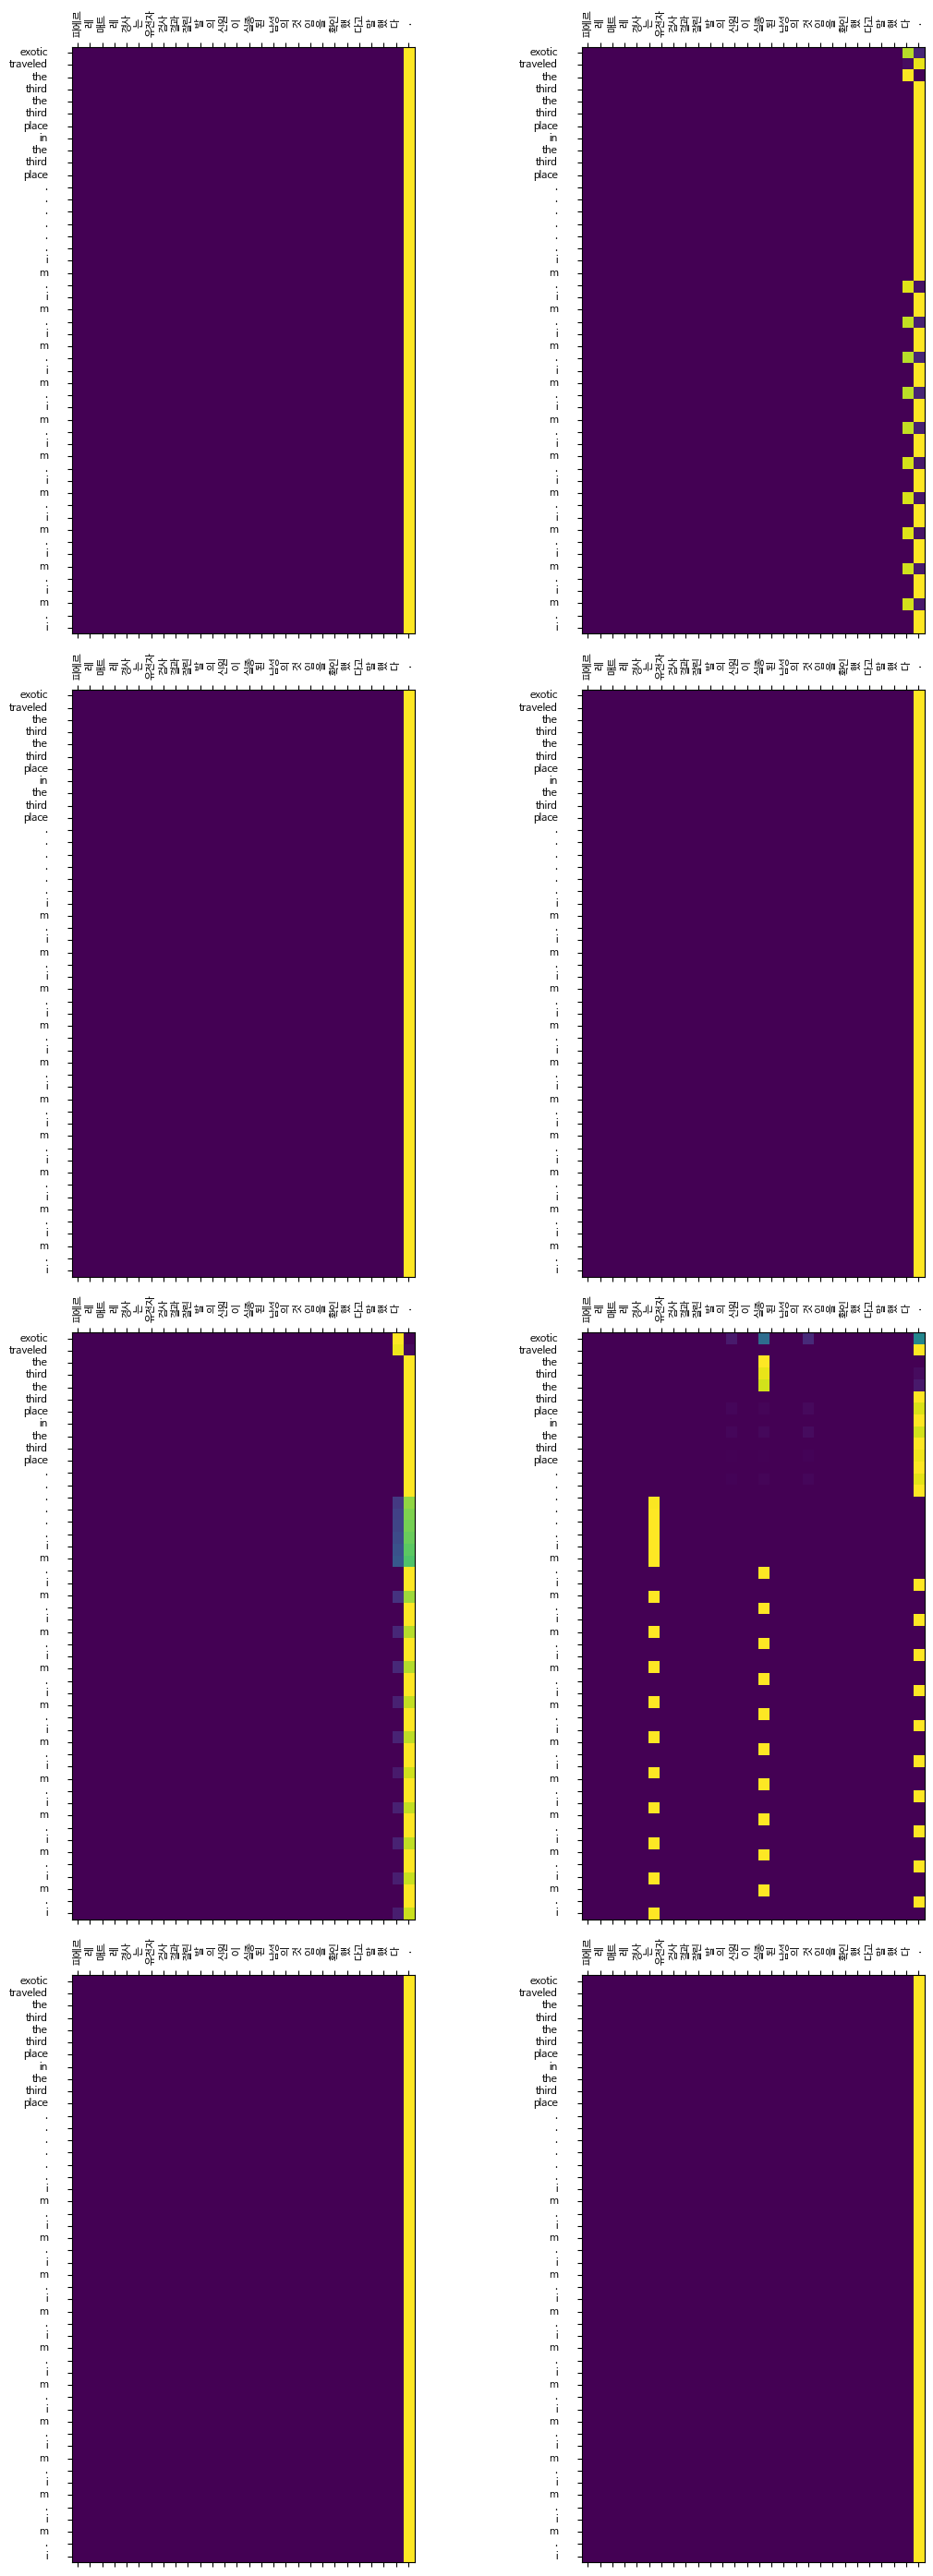

In [24]:
def display_attention(sentence, translation, attention, n_heads=8, n_rows=4, n_cols=2):
    """어텐션 맵을 시각화합니다."""
    assert n_rows * n_cols == n_heads

    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    font_prop = fm.FontProperties(fname=font_path, size=8)

    fig = plt.figure(figsize=(12, 28))  # x축을 조금 넓혀서 압축 줄임 (10->12)

    # 번역된 문장과 원본 문장을 토큰 단위로 분리
    sentence_tokens = sentence.split()
    translation_tokens = translation.split()

    for i in range(n_heads):
        ax = fig.add_subplot(n_rows, n_cols, i + 1)

        # attention shape: (head_idx, tgt_len, src_len)
        _attention = attention.squeeze(0)[i].cpu().detach().numpy()

        # extent 명시: (-0.5, src_len-0.5, tgt_len-0.5, -0.5)로 ticks와 맞춤
        src_len = len(sentence_tokens)
        tgt_len = len(translation_tokens)
        cax = ax.matshow(_attention, cmap='viridis', extent=[-0.5, src_len - 0.5, tgt_len - 0.5, -0.5])

        # 눈금 위치 설정
        ax.set_xticks(range(src_len))
        ax.set_yticks(range(tgt_len))

        # 라벨 설정: ha/va로 중앙 정렬
        ax.set_xticklabels(sentence_tokens, rotation=90, fontproperties=font_prop, ha='center', va='center')
        ax.set_yticklabels(translation_tokens, fontproperties=font_prop, ha='right', va='center')

        ax.tick_params(labelsize=8, pad=15)  # pad로 텍스트와 tick 간격 미세 조정

    plt.tight_layout()  # subplot 간 여백 자동 조정 (밀림 방지)
    plt.show()

display_attention(src, translation, attention[-1])